# Import libraries

In [1]:
import os
import warnings

import math

import re

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns

from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import FuncFormatter

In [2]:
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 50)

In [3]:
sns.set_theme()

mpl.rcParams.update({
    "font.family": ["Comic Sans MS", "DejaVu Sans", "Arial"],
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [4]:
path_to_save = './../results/00a_pub_stats'

# Loading data

In [5]:
path_to_data = './../data/additional_data/pub_stats/publications_over_time.csv'

In [6]:
data = pd.read_csv(path_to_data, sep=';')

print(data.shape)
data

(6, 4)


,Full_Topic,Short_Topic,Papers,Ratio
0,Graphene,Graphene,259162,100%
1,Graphene oxide,Graphene oxide,80629,31%
2,FTIR research keywords combined with graphene ...,FTIR + graphene oxide,9759,12%
3,"""FTIR""+""surface"" research keywords combined wi...",FTIR + surface + graphene oxide,4380,5%
4,Machine learning,Machine learning,1564,"0,60%"
5,Machine learning research keywords combined wi...,Machine learning + graphene oxide,207,"0,08%"


# Data visualization

*Data wrangling*

In [7]:
df_plot = (
    data.loc[:, ["Short_Topic", "Papers", "Ratio"]]
        .sort_values("Papers", ascending=False)
        .reset_index(drop=True)
)

print(df_plot.shape)
df_plot

(6, 3)


,Short_Topic,Papers,Ratio
0,Graphene,259162,100%
1,Graphene oxide,80629,31%
2,FTIR + graphene oxide,9759,12%
3,FTIR + surface + graphene oxide,4380,5%
4,Machine learning,1564,"0,60%"
5,Machine learning + graphene oxide,207,"0,08%"


*Base parameters and functions*

In [8]:
def fmt_int(n):
    return f"{int(n):,}".replace(",", "")

In [9]:
label_fs = 16
tick_fs  = 12
bar_fs   = 12

order = df_plot["Short_Topic"].tolist()

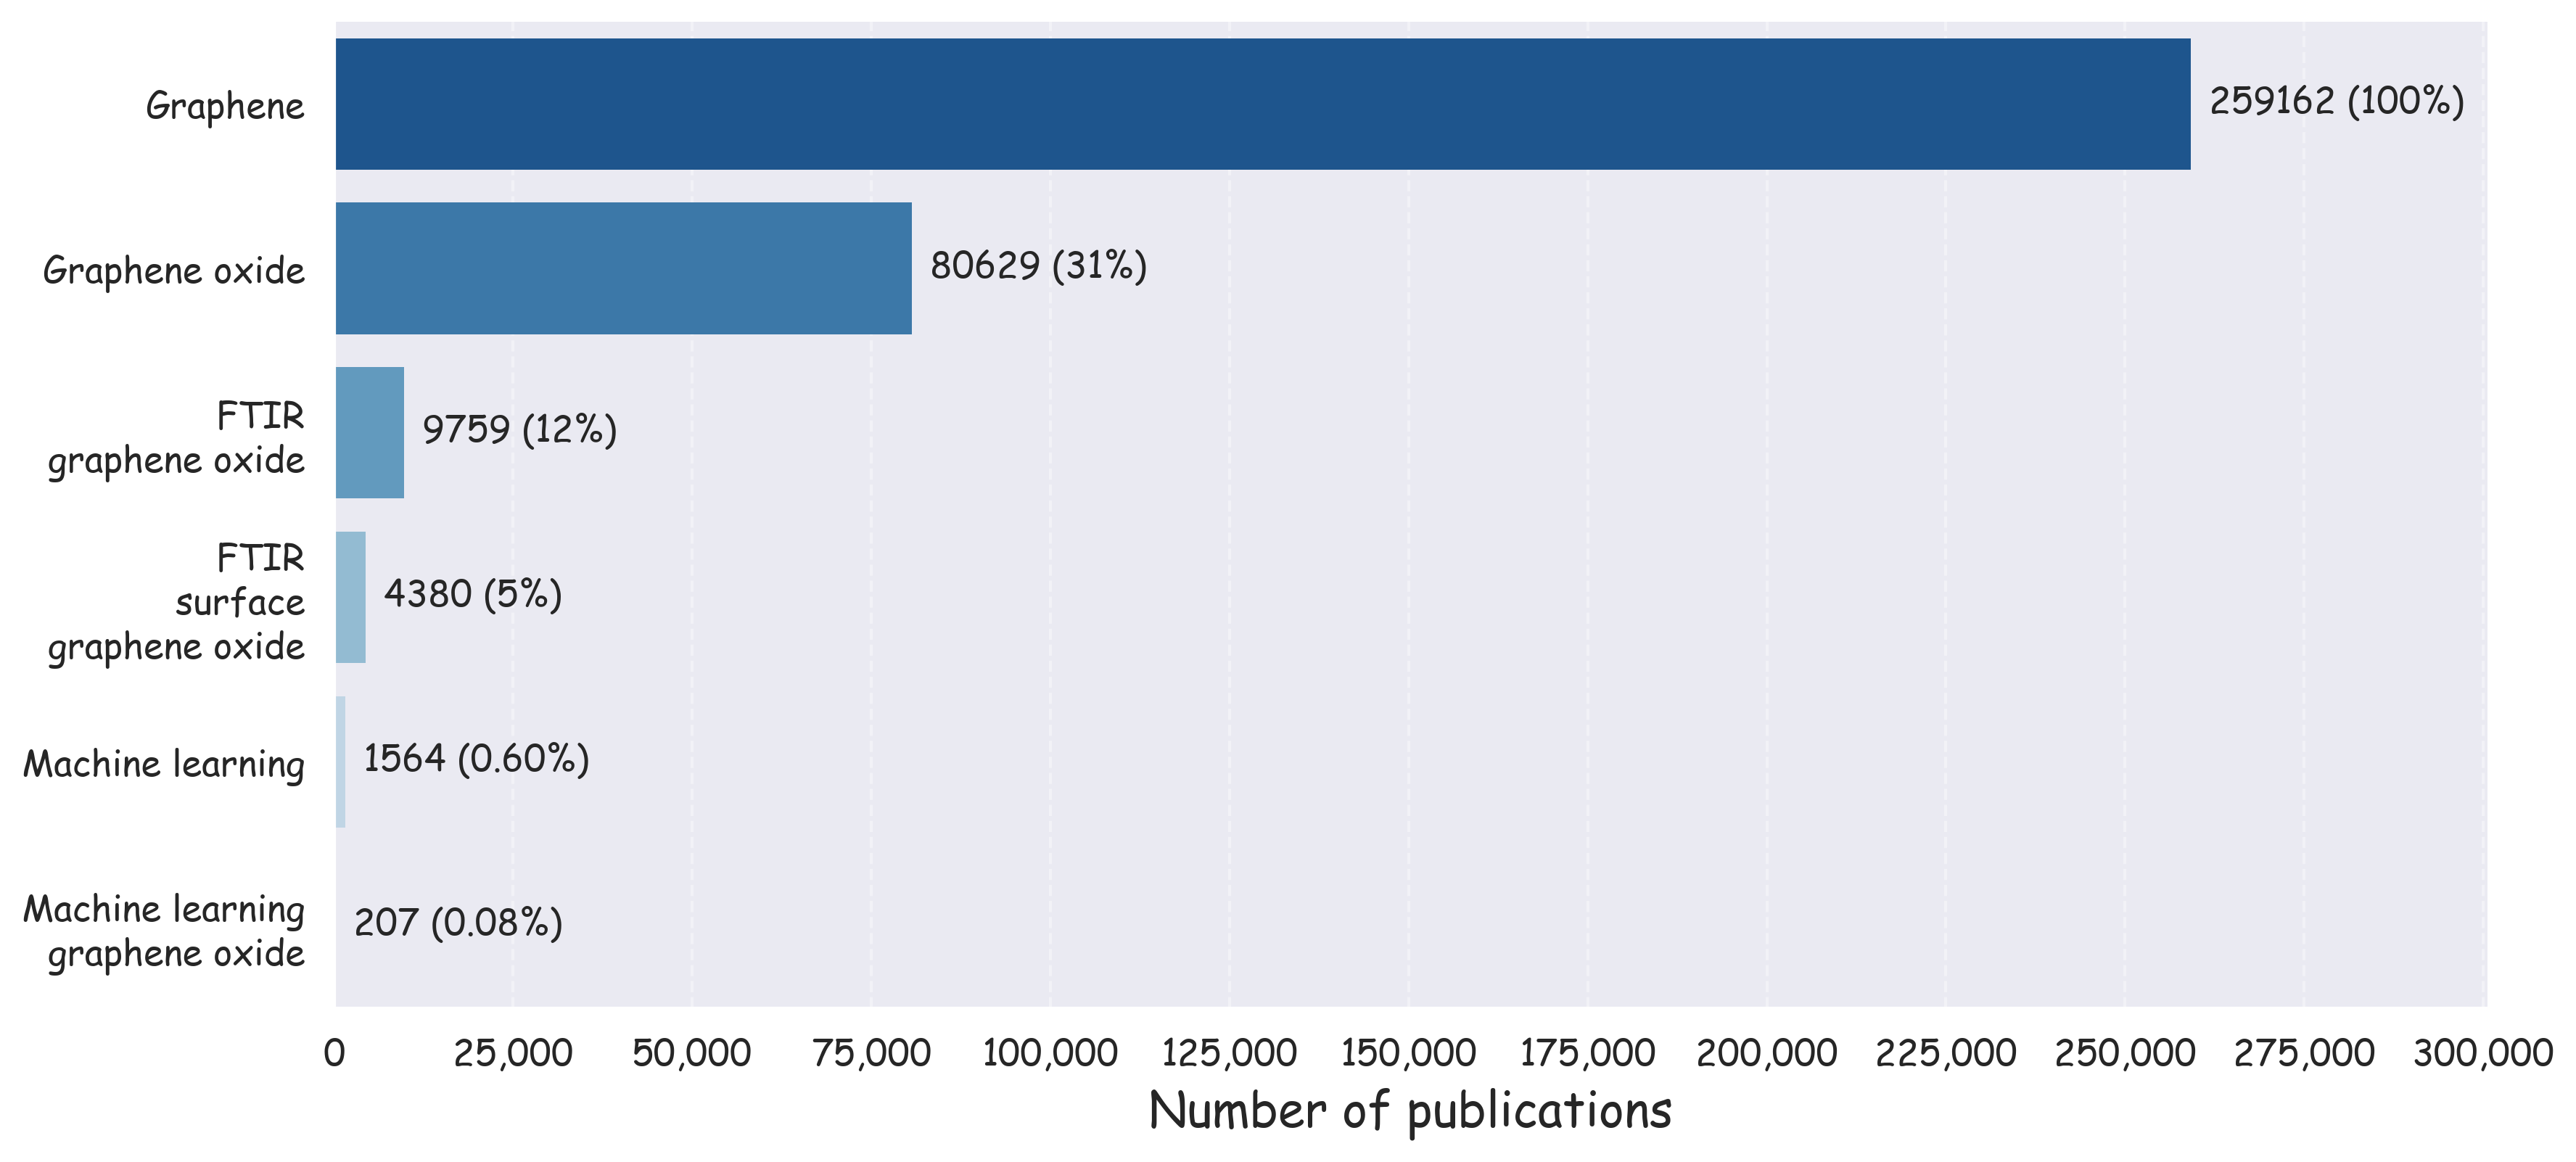

In [10]:
fig, ax = plt.subplots(figsize=(12, 5.5), dpi=300)

bars = sns.barplot(
    data=df_plot,
    x="Papers",
    y="Short_Topic",
    order=order,
    orient="h",
    ax=ax,
    palette="Blues_r",
    edgecolor="none"
)

ax.set_xlabel("Number of publications", fontsize=label_fs)
ax.set_ylabel("", fontsize=label_fs)

ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.tick_params(axis="both", labelsize=tick_fs)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ",")))

ax.xaxis.set_major_locator(MultipleLocator(25_000))

ax.set_xlim(0, df_plot['Papers'].max() * 1.16)

ax.set_yticklabels([re.sub(r"\s*\+\s*", "\n", s) for s in order], fontsize=tick_fs)

pad_pts = 6

for bar, (papers, ratio) in zip(ax.patches, zip(df_plot["Papers"], df_plot["Ratio"])):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.annotate(
        f"{fmt_int(papers)} ({ratio.replace(',', '.')})",
        xy=(x, y), xytext=(pad_pts, 0),
        textcoords="offset points",
        va="center", ha="left",
        fontsize=bar_fs
    )

plt.tight_layout()
plt.savefig(f"{path_to_save}/publications_barplot.png", dpi=1800, bbox_inches="tight")
plt.show()